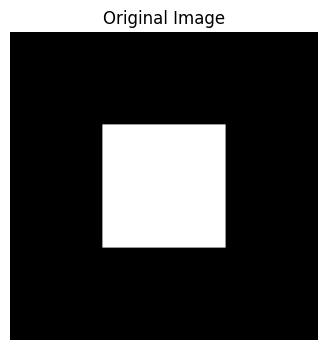

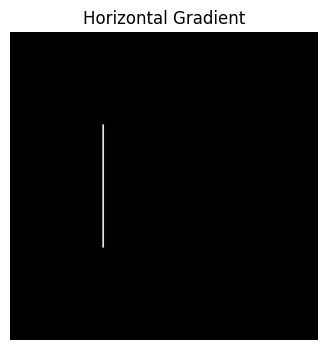

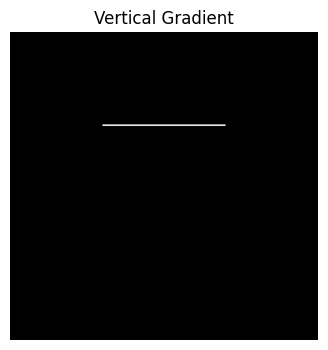

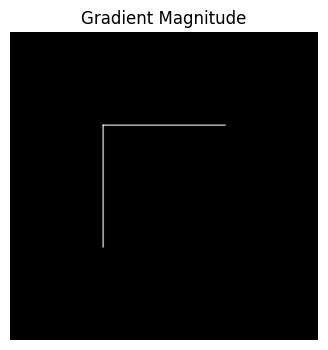

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def topic1_basic_gradient():

    # create synthetic image
    img = np.zeros((200,200), dtype=np.uint8)
    img[60:140,60:140] = 255

    # kernels
    kernel_x = np.array([[-1,1]], dtype=np.float32)
    kernel_y = np.array([[-1],[1]], dtype=np.float32)

    # gradients
    gx = cv2.filter2D(img,-1,kernel_x)
    gy = cv2.filter2D(img,-1,kernel_y)

    # magnitude
    magnitude = np.sqrt(gx.astype(np.float32)**2 + gy.astype(np.float32)**2)

    show(img,"Original Image")
    show(gx,"Horizontal Gradient")
    show(gy,"Vertical Gradient")
    show(magnitude,"Gradient Magnitude")

topic1_basic_gradient()

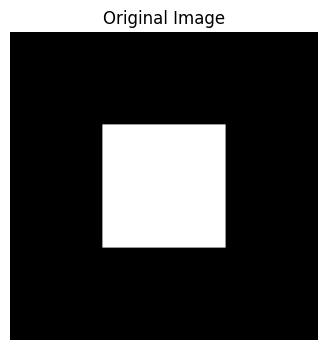

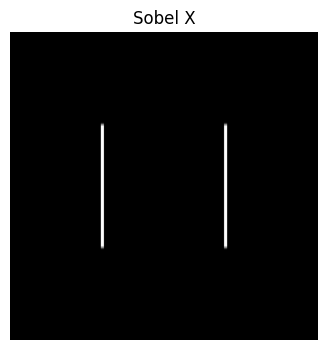

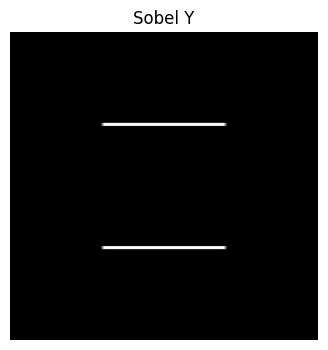

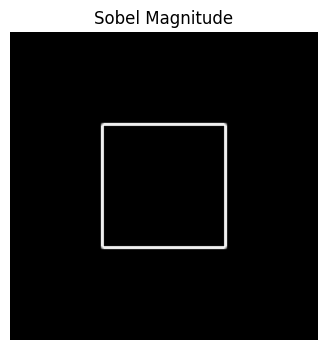

In [15]:
def topic2_sobel():

    img = np.zeros((200,200), dtype=np.uint8)
    img[60:140,60:140] = 255

    sobel_x = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
    sobel_y = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)

    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

    show(img,"Original Image")
    show(np.abs(sobel_x),"Sobel X")
    show(np.abs(sobel_y),"Sobel Y")
    show(sobel_mag,"Sobel Magnitude")

topic2_sobel()

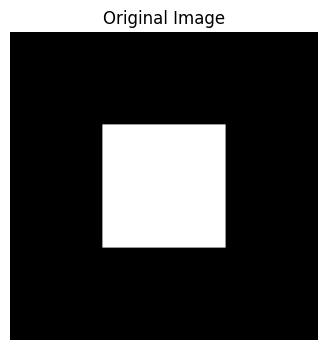

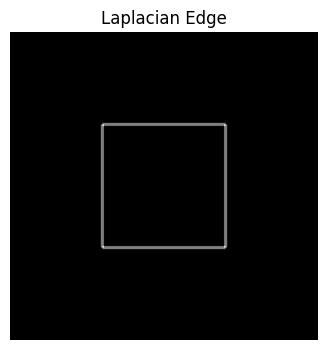

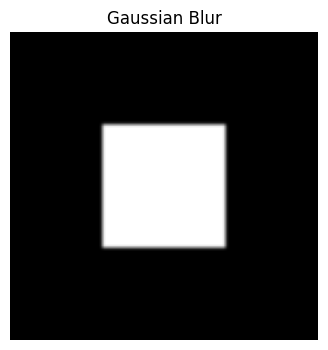

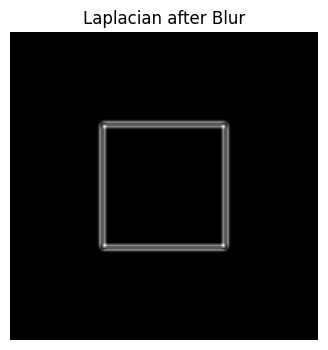

In [16]:
def topic3_laplacian():

    img = np.zeros((200,200), dtype=np.uint8)
    img[60:140,60:140] = 255

    lap = cv2.Laplacian(img,cv2.CV_64F)

    blur = cv2.GaussianBlur(img,(5,5),0)
    lap_blur = cv2.Laplacian(blur,cv2.CV_64F)

    show(img,"Original Image")
    show(np.abs(lap),"Laplacian Edge")
    show(blur,"Gaussian Blur")
    show(np.abs(lap_blur),"Laplacian after Blur")

topic3_laplacian()

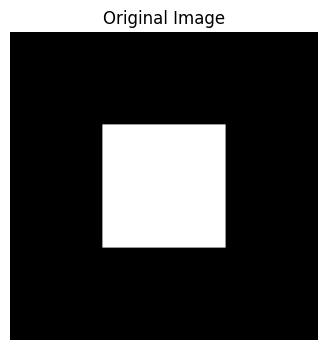

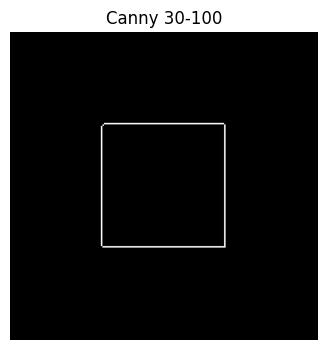

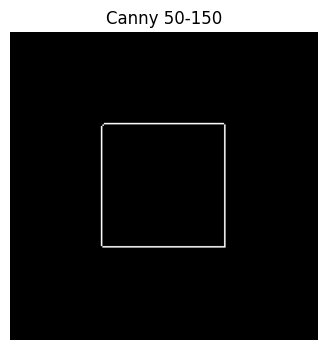

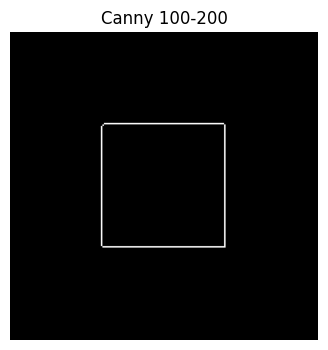

In [17]:
def topic4_canny():

    img = np.zeros((200,200), dtype=np.uint8)
    img[60:140,60:140] = 255

    edges1 = cv2.Canny(img,30,100)
    edges2 = cv2.Canny(img,50,150)
    edges3 = cv2.Canny(img,100,200)

    show(img,"Original Image")
    show(edges1,"Canny 30-100")
    show(edges2,"Canny 50-150")
    show(edges3,"Canny 100-200")

topic4_canny()

Overall Explanation of the Tasks

In this assignment, we explored several fundamental edge detection techniques used in image processing and computer vision. Edge detection is an important step in analyzing images because edges represent significant changes in intensity, which often correspond to object boundaries, shapes, and important structural information in an image.

The first task focused on computing basic image gradients using simple convolution kernels. Gradients measure how quickly pixel intensities change in horizontal and vertical directions. By calculating horizontal and vertical gradients and combining them into a gradient magnitude, we can highlight regions in the image where strong intensity changes occur, which typically correspond to edges.

The second task introduced the Sobel operator, which is a widely used gradient-based edge detection method. The Sobel operator improves basic gradient detection by using specialized kernels that combine smoothing and differentiation. This helps reduce noise and produces clearer edge responses. By computing both horizontal and vertical Sobel gradients and combining them, we can obtain a stronger representation of edge strength.

The third task explored the Laplacian operator, which detects edges by calculating the second derivative of the image intensity. Unlike gradient-based methods that detect edges in specific directions, the Laplacian detects edges in all directions simultaneously. However, since it is sensitive to noise, it is often combined with Gaussian smoothing to improve stability and reduce unwanted responses.

Finally, the fourth task implemented the Canny edge detector, which is one of the most advanced and widely used edge detection algorithms. The Canny method performs multiple steps including noise reduction, gradient calculation, non-maximum suppression, and double thresholding. This process results in thin, well-defined edges and significantly reduces false detections, making it very effective for real-world applications.

Overall, these tasks demonstrate different approaches to detecting edges in images, starting from simple gradient methods and progressing to more advanced algorithms like Canny. Understanding these techniques is essential in computer vision because edge detection is widely used in object recognition, image segmentation, medical imaging, autonomous driving systems, and many other applications.